Import Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

Load Dataset

In [49]:
df = pd.read_csv("../data/raw/marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


Understand Dataset

In [50]:
df.shape

(2240, 29)

In [51]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [53]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [54]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

Data Cleaning

Check Missing Values

In [56]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Handle Missing Income

In [57]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [58]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Convert Date Column

In [59]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[us]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null   int64  

Remove Constant Columns

In [61]:
df[["Z_CostContact", "Z_Revenue"]].nunique()

Z_CostContact    1
Z_Revenue        1
dtype: int64

In [62]:
df.drop(columns=["Z_CostContact", "Z_Revenue"], inplace=True)

In [63]:
df.to_csv("../data/processed/marketing_campaign_clean.csv", index=False)

Exploratory Data Analysis (EDA)

Load Cleaned Data

In [64]:
df = pd.read_csv("../data/processed/marketing_campaign_clean.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


Dataset Overview

In [65]:
print("Shape:", df.shape)

df.describe().T

Shape: (2240, 27)


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2240.0,52237.975446,25037.955891,1730.0,35538.75,51381.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


Distribution of Numerical Features

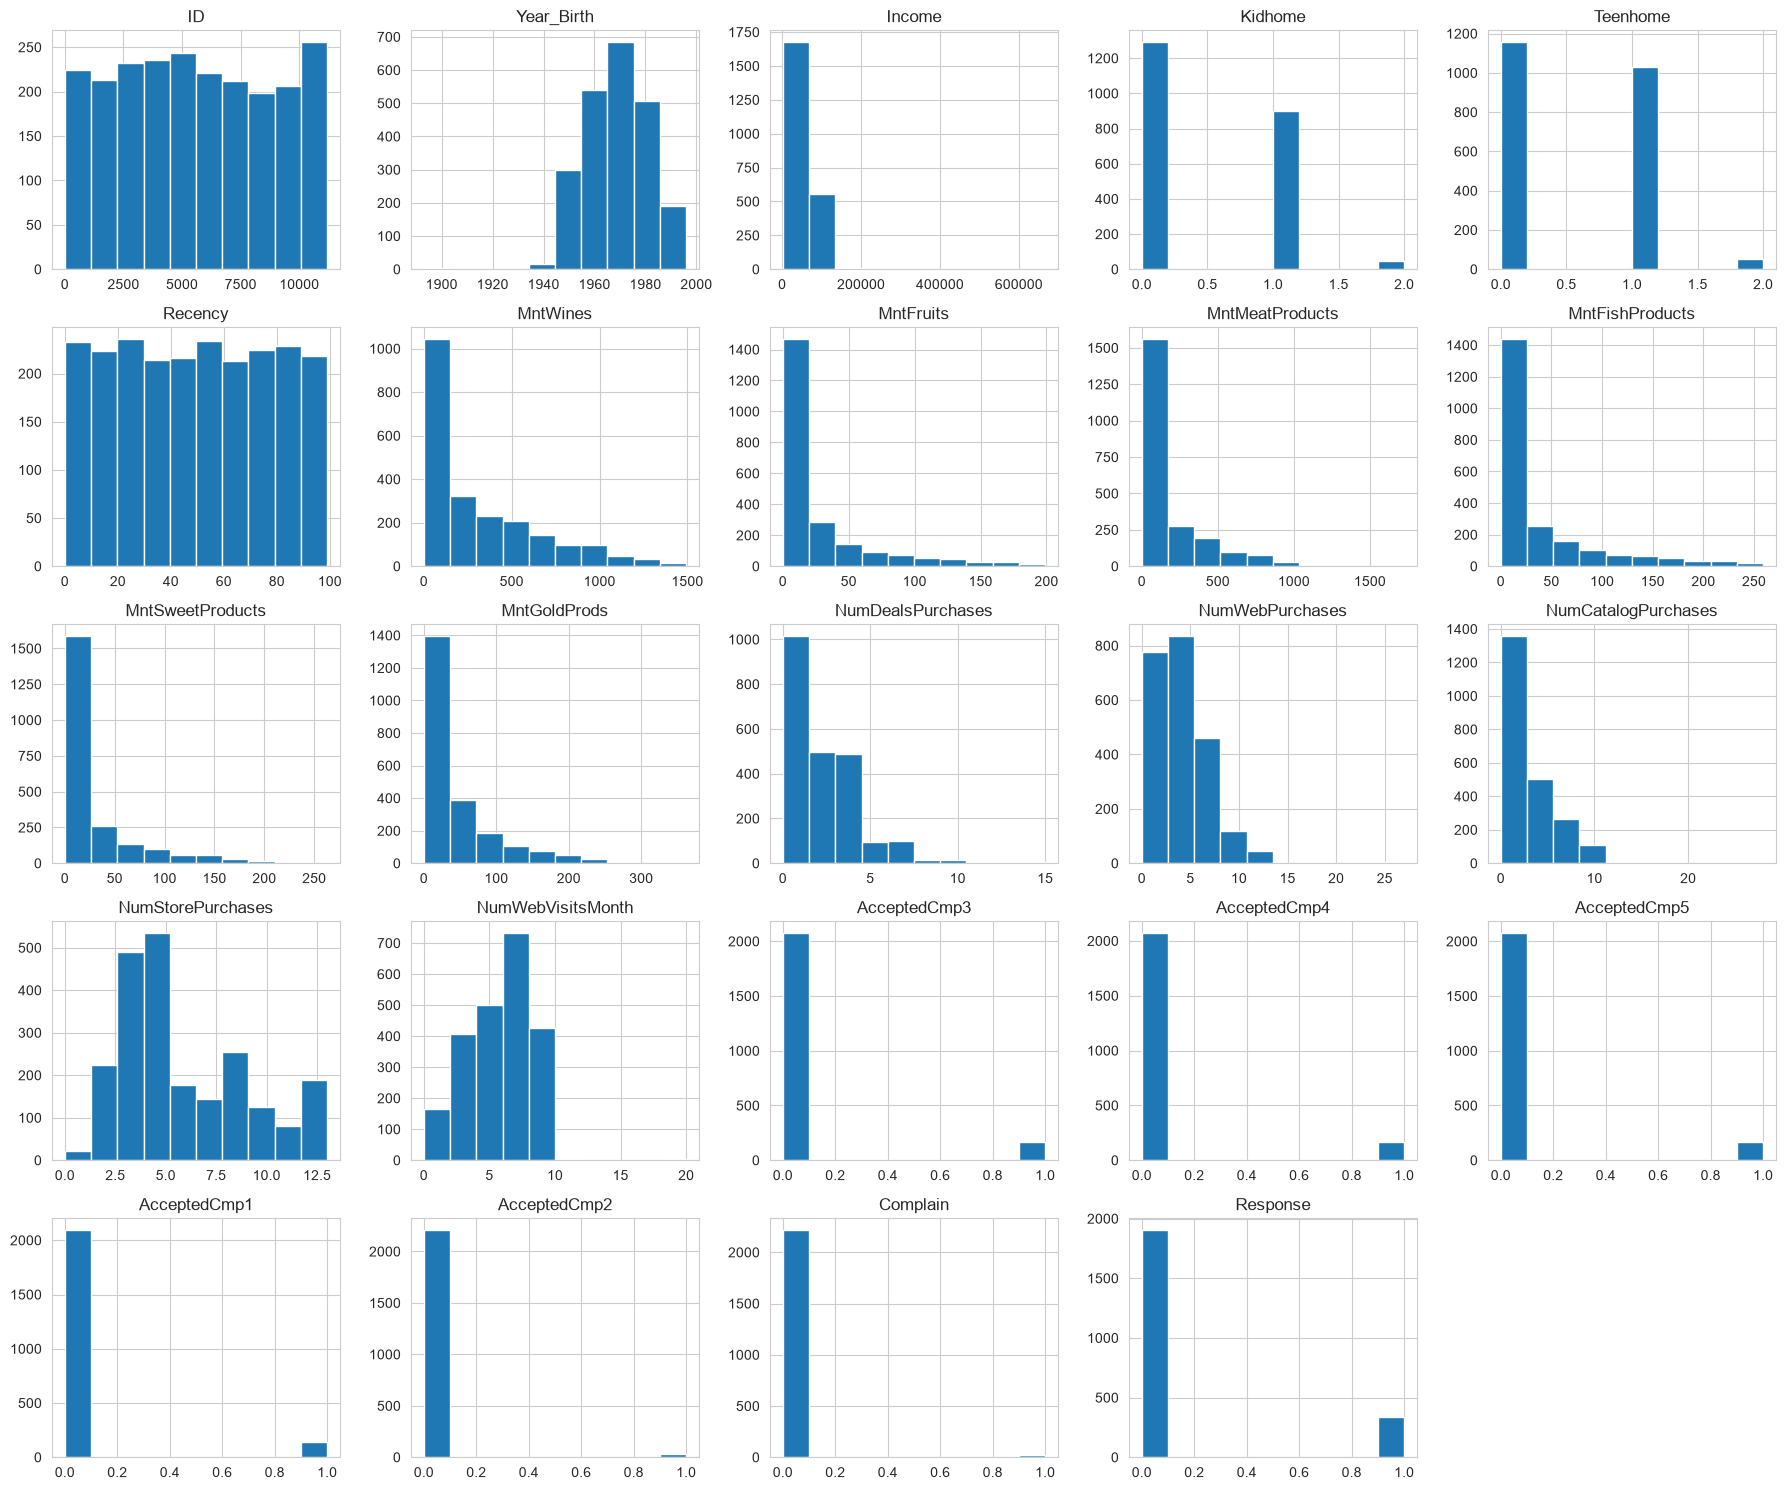

In [66]:
df.hist(figsize=(18, 15))
plt.tight_layout()
plt.show()

Correlation Heatmap

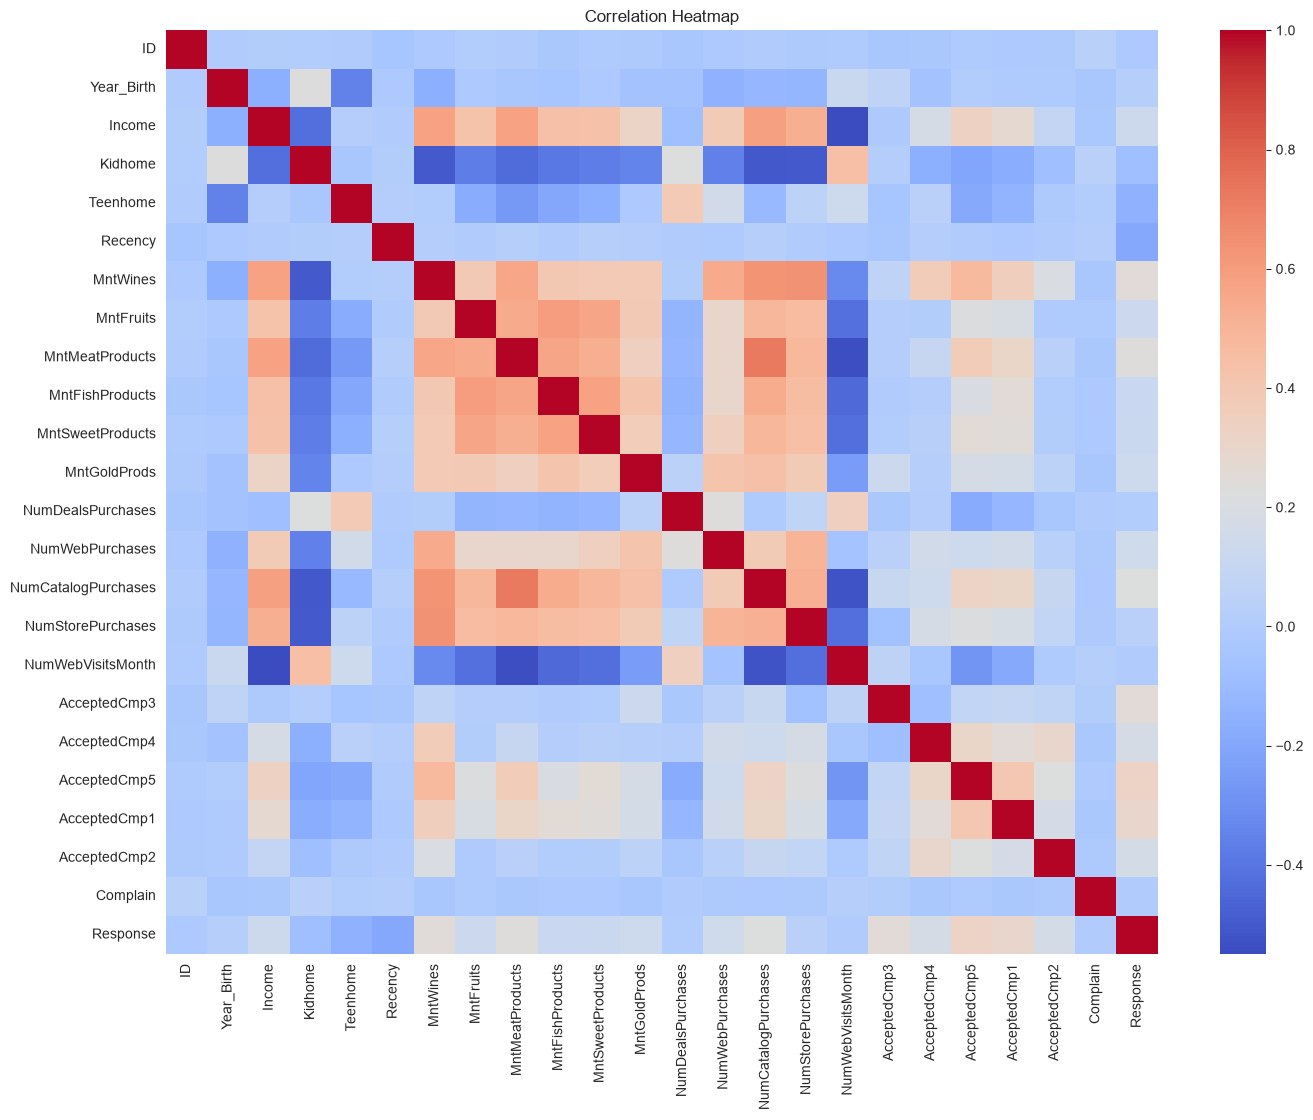

In [67]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

Income Distribution

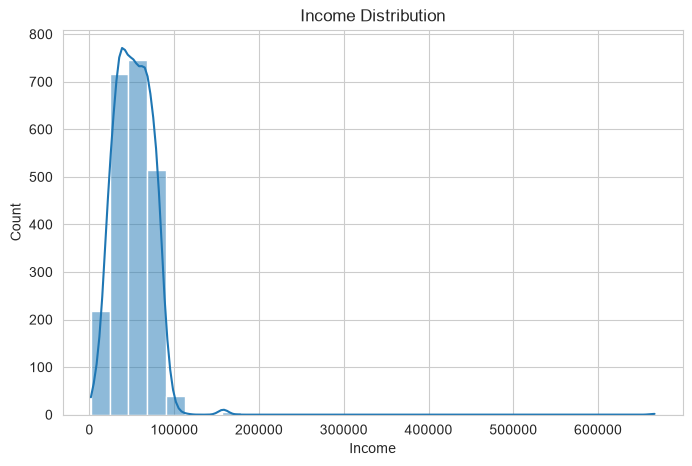

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(df["Income"], bins=30, kde=True)

plt.title("Income Distribution")
plt.show()

Response Count

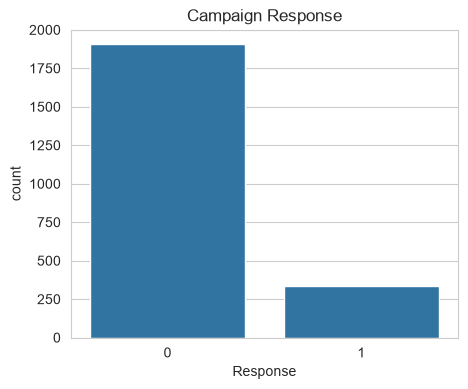

In [69]:
plt.figure(figsize=(5,4))

sns.countplot(x="Response", data=df)

plt.title("Campaign Response")
plt.show()

Education Distribution

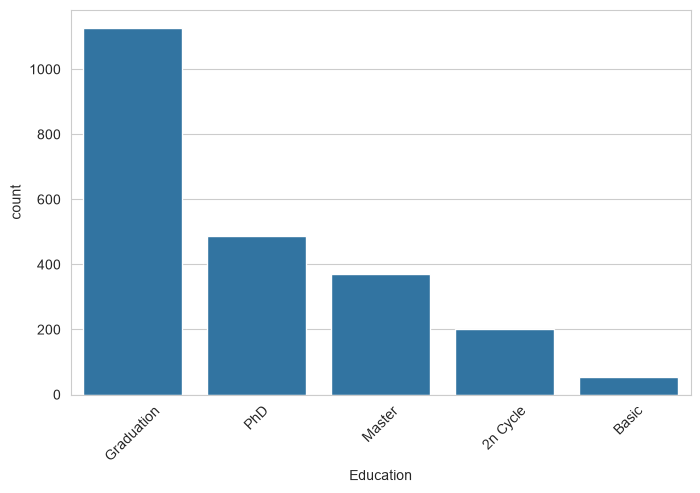

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Education",
    data=df,
    order=df["Education"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

Marital Status Distribution

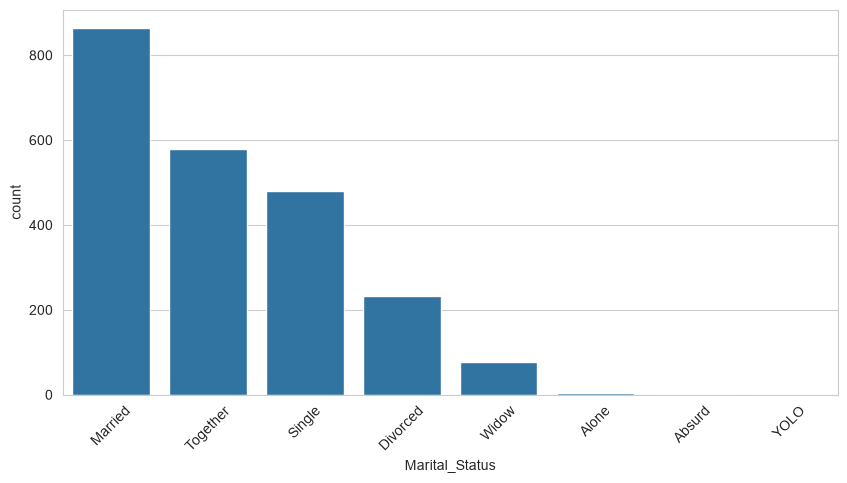

In [71]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Marital_Status",
    data=df,
    order=df["Marital_Status"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

Spending Analysis

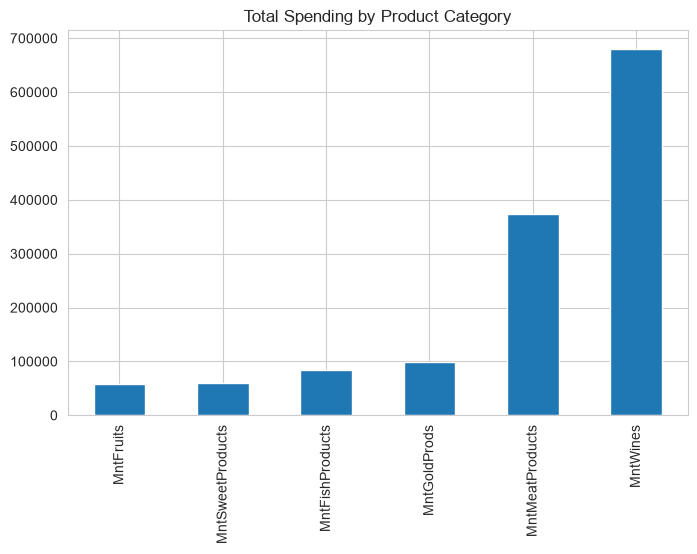

In [72]:
spending = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df[spending].sum().sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Spending by Product Category")

plt.show()

Boxplots (Outlier Detection)

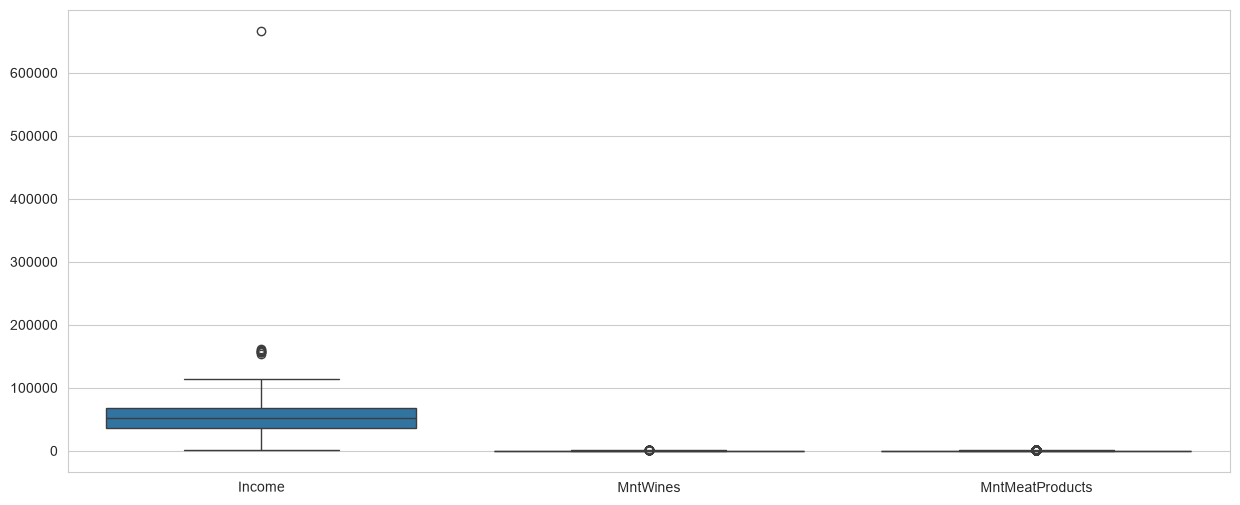

In [73]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df[["Income","MntWines","MntMeatProducts"]])

plt.show()

Income vs Response

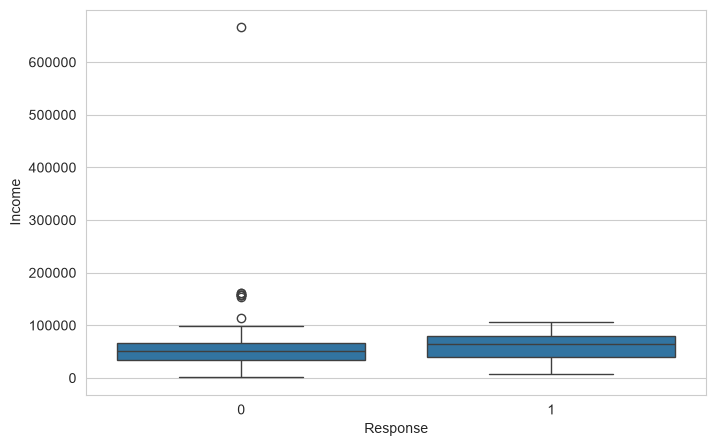

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Response", y="Income", data=df)

plt.show()

Pairplot

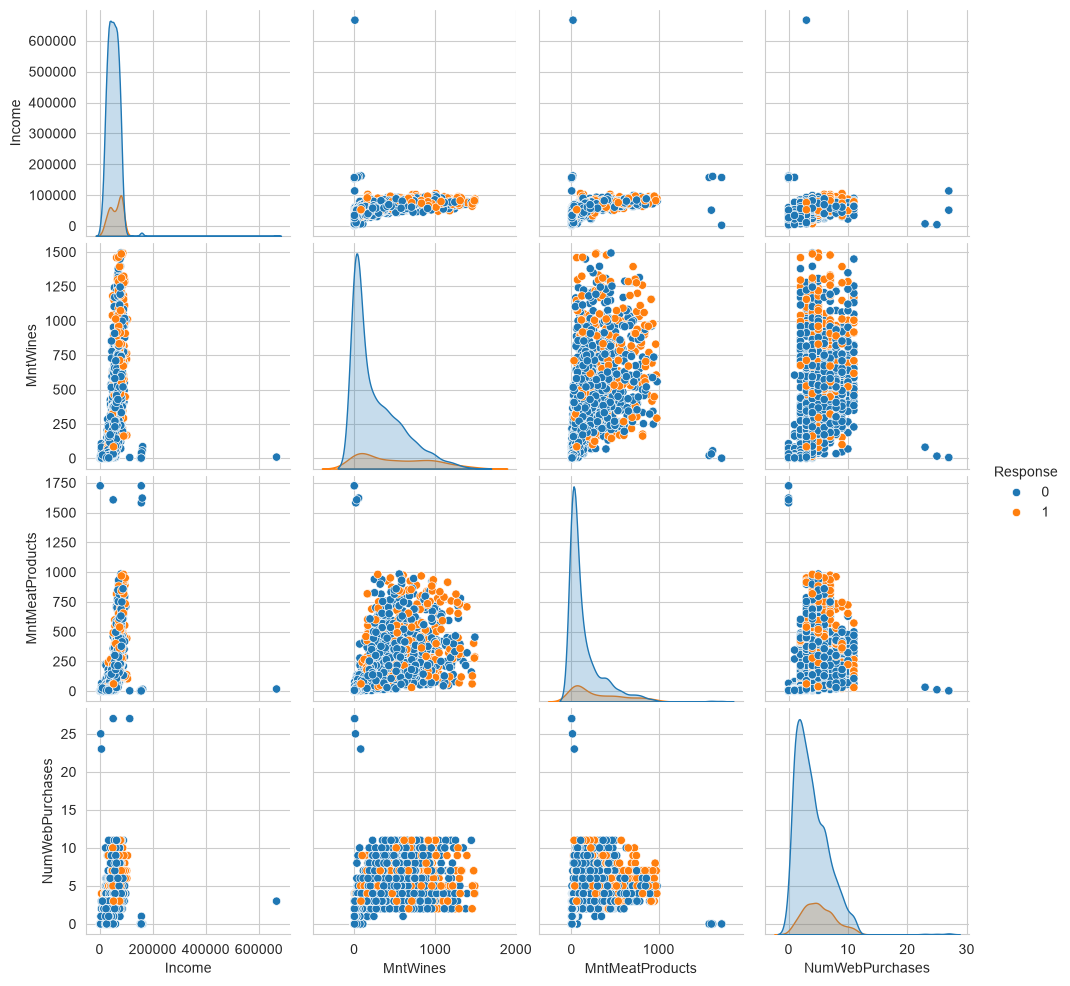

In [75]:
sns.pairplot(
    df[
        [
            "Income",
            "MntWines",
            "MntMeatProducts",
            "NumWebPurchases",
            "Response"
        ]
    ],
    hue="Response"
)

plt.show()

Feature Engineering

Load Cleaned Data

In [76]:
df = pd.read_csv("../data/processed/marketing_campaign_clean.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


Customer Age

In [77]:
current_year = 2026

df["Age"] = current_year - df["Year_Birth"]

Customer Tenure (Days)

In [78]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

df["Customer_Tenure"] = (
    pd.Timestamp("2026-01-01") - df["Dt_Customer"]
).dt.days

Family Size

In [79]:
df["Family_Size"] = df["Kidhome"] + df["Teenhome"] + 1

Total Spending

In [80]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

Total Purchases

In [81]:
df["Total_Purchases"] = (
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

Total Accepted Campaigns

In [82]:
df["Accepted_Campaigns"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

Total Children

In [83]:
df["Children"] = df["Kidhome"] + df["Teenhome"]

In [84]:
df[[
    "Age",
    "Customer_Tenure",
    "Family_Size",
    "Children",
    "Total_Spending",
    "Total_Purchases",
    "Accepted_Campaigns"
]].head()

,Age,Customer_Tenure,Family_Size,Children,Total_Spending,Total_Purchases,Accepted_Campaigns
0,69,4867,1,0,1617,22,0
1,72,4317,3,2,27,4,0
2,61,4516,1,0,776,20,0
3,42,4343,2,1,53,6,0
4,45,4365,2,1,422,14,0


Save Processed Dataset

In [85]:
df.to_csv("../data/processed/marketing_campaign_feature_engineered.csv", index=False)

Classification

Load Dataset

In [86]:
df = pd.read_csv("../data/processed/marketing_campaign_feature_engineered.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,Accepted_Campaigns,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,4867,1,1617,22,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,4317,3,27,4,0,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,4516,1,776,20,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,4343,2,53,6,0,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,4365,2,422,14,0,1


Encode Categorical Columns

In [87]:
categorical_cols = ["Education", "Marital_Status"]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Drop Unnecessary Columns

In [88]:
X = df.drop(columns=["ID", "Dt_Customer", "Response"])

y = df["Response"]

Train-Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
X.isnull().sum()[X.isnull().sum() > 0]

Series([], dtype: int64)

Scale the features

In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression (Baseline)

In [92]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

Random Forest

In [93]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

XGBoost

In [94]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

Evaluation Function

In [95]:
def evaluate(y_true, pred, prob):
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, prob)
    }

Compare Models

In [96]:
results = pd.DataFrame([
    evaluate(y_test, lr_pred, lr_prob),
    evaluate(y_test, rf_pred, rf_prob),
    evaluate(y_test, xgb_pred, xgb_prob)
],
index=[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
])

results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.883929,0.741935,0.343284,0.469388,0.877013
Random Forest,0.886161,0.785714,0.328358,0.463158,0.878442
XGBoost,0.890625,0.750000,0.402985,0.524272,0.903416


Best Model

In [97]:
results.sort_values("ROC_AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.890625,0.750000,0.402985,0.524272,0.903416
Random Forest,0.886161,0.785714,0.328358,0.463158,0.878442
Logistic Regression,0.883929,0.741935,0.343284,0.469388,0.877013


Feature Importance (Random Forest)

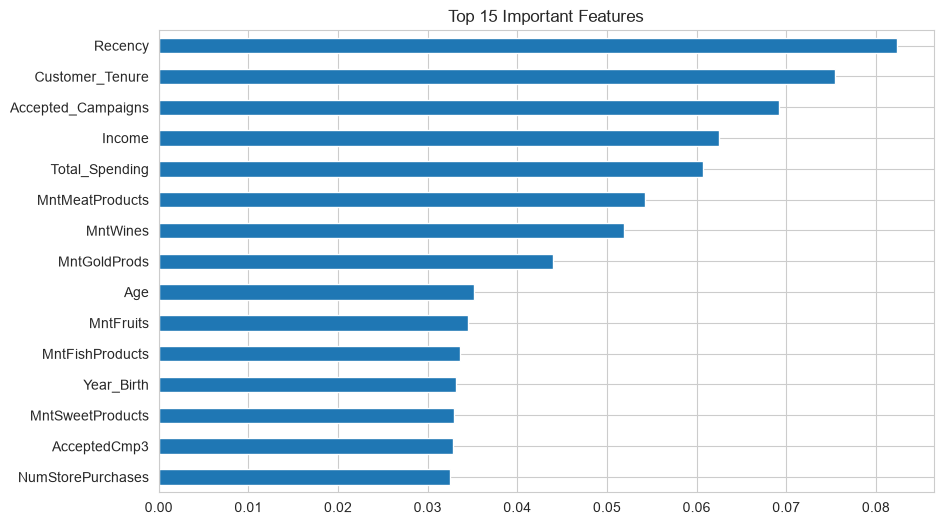

In [98]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

Confusion Matrix

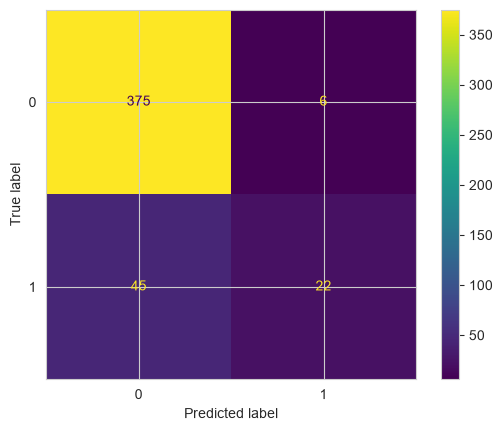

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

Clustering

Load Dataset

In [100]:
df = pd.read_csv("../data/processed/marketing_campaign_feature_engineered.csv")

Encode Categorical Columns

In [101]:
le = LabelEncoder()

df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])

Remove Unnecessary Columns

In [102]:
X = df.drop(columns=["ID", "Dt_Customer", "Response"])

Scale Data

In [103]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

K-Means

Elbow Method

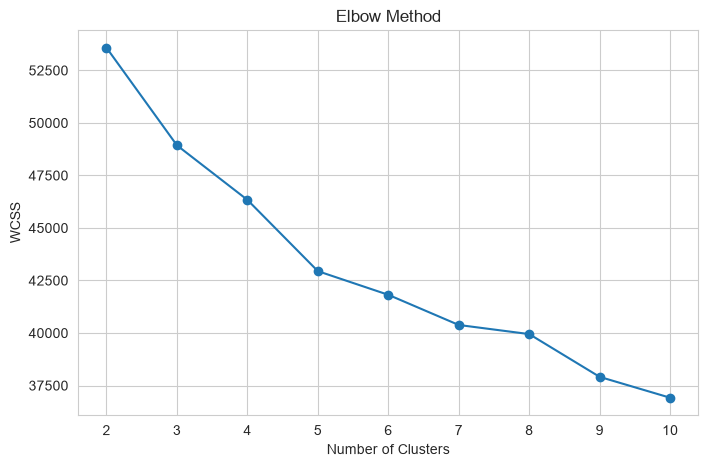

In [104]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

Train KMeans

In [105]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

Silhouette Score

In [106]:
score = silhouette_score(
    X_scaled,
    df["KMeans_Cluster"]
)

print(score)

0.12005859085945679


DBSCAN

In [107]:
dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
-1    1426
 1     364
 0     223
 3     113
 2      56
 6      23
 5      13
 4       8
 9       5
 7       5
 8       4
Name: count, dtype: int64

PCA Visualization

In [108]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

Cluster Visualization

KMeans Plot

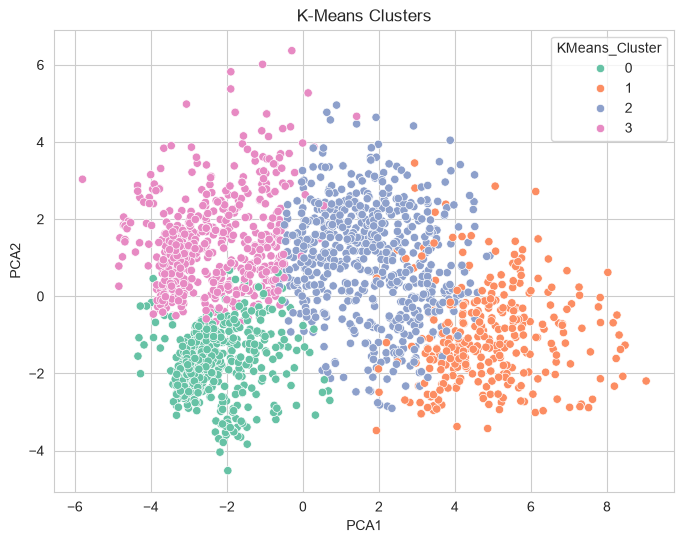

In [109]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="KMeans_Cluster",
    palette="Set2"
)

plt.title("K-Means Clusters")

plt.show()

DBSCAN Plot

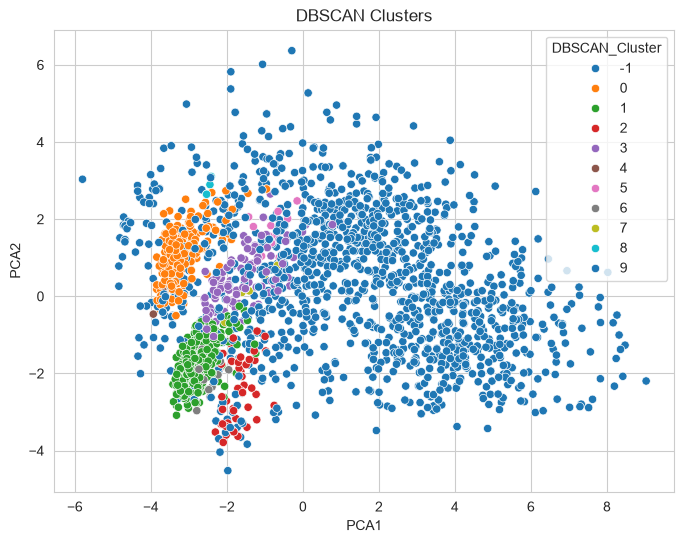

In [110]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="DBSCAN_Cluster",
    palette="tab10"
)

plt.title("DBSCAN Clusters")

plt.show()

Customer Segmentation

Customer Profiling

In [111]:
cluster_profile = df.groupby("KMeans_Cluster")[[
    "Income",
    "Age",
    "Total_Spending",
    "Total_Purchases"
]].mean()

cluster_profile

,Income,Age,Total_Spending,Total_Purchases
KMeans_Cluster,,,,
0,30772.725203,48.642276,105.390244,5.957724
1,81371.947143,55.102857,1570.445714,19.568571
2,63607.400298,61.575893,925.300595,18.866071
3,44549.725539,62.247098,200.190713,8.112769


Save Dataset

In [112]:
df.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

Business Insights

# Business Impact

If this system is deployed in a real organization:

- Marketing campaigns can target customers with the highest probability of responding.
- Customer acquisition costs can be reduced by avoiding low-probability targets.
- Premium customers can receive personalized offers, improving customer retention.
- Product recommendations can be customized based on customer segments.
- Data-driven customer intelligence enables more efficient and profitable marketing decisions.